In [1]:
from google.colab import files

uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv
Saving IDS_mapping.csv to IDS_mapping.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

In [3]:
df = pd.read_csv("diabetic_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (101766, 50)


In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print(df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [6]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [8]:
df = df.replace("?", np.nan)

print("Missing values replaced!")

Missing values replaced!


In [9]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [10]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_drop)

print("Columns removed:", columns_to_drop)
print("New shape:", df.shape)

Columns removed: ['weight', 'payer_code', 'medical_specialty']
New shape: (101766, 47)


In [11]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print(df["target"].value_counts())

target
0    90409
1    11357
Name: count, dtype: int64


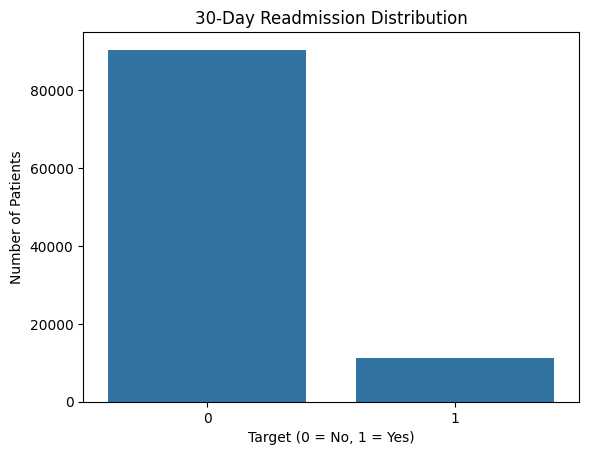

In [12]:
sns.countplot(x="target", data=df)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

In [13]:
features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "insulin",
    "diabetesMed"
]

X = df[features]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 18)
y shape: (101766,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (81412, 18)
Testing data: (20354, 18)


In [15]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical features: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'insulin', 'diabetesMed']


In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [18]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [19]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [22]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [23]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.58276168 0.32483778 0.4424493  0.65604827 0.38016776 0.20414011
 0.31954151 0.36440508 0.68631436 0.59967669]


In [24]:
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:10])

[1 0 0 1 0 0 0 0 1 1]


In [25]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.641028173503883


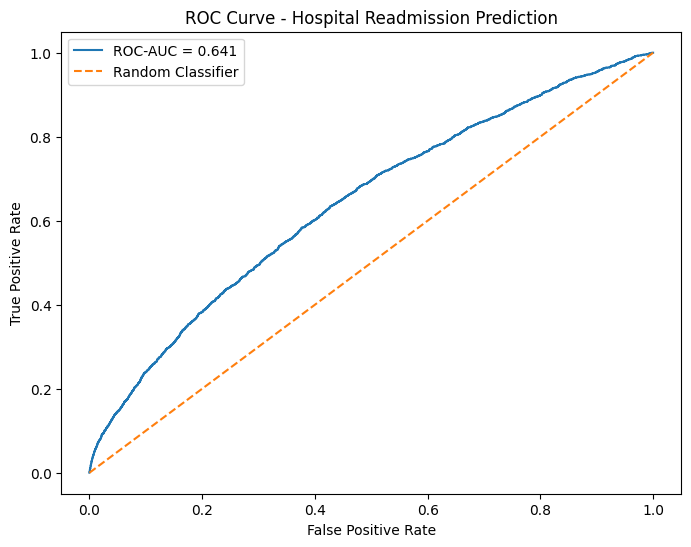

In [26]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()
plt.show()

In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11899  6184]
 [ 1035  1236]]


In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(
    y_test,
    y_pred,
    zero_division=0
))

print("Recall:", recall_score(
    y_test,
    y_pred,
    zero_division=0
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy: 0.6453276997150438
Precision: 0.16657681940700808
Recall: 0.5442536327608983

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.26      2271

    accuracy                           0.65     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.65      0.71     20354

